In [ ]:
%load_ext autoreload
%autoreload 2

In [14]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../core')
from config import processed_data_path, results_path
from model_func import save_model, save_report, save_figure
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, f1_score

In [2]:
X_path = os.path.join(processed_data_path, 'X_data.npy')
y_path = os.path.join(processed_data_path, 'y_data.npy')
feature_names_path = os.path.join(processed_data_path, 'feature_names.npy')

X = np.load(X_path)
y = np.load(y_path)
feature_names = np.load(feature_names_path, allow_pickle=True)

In [3]:
nlp_indices = [i for i, name in enumerate(feature_names) if 'nlp_' in name]
print(nlp_indices)

[3, 4]


In [4]:
X_struct = np.delete(X, nlp_indices, axis=1)
print(f"Training on {X_struct.shape[1]} structured features only.")

Training on 19 structured features only.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_struct, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
models = {
    "Logistic_Regression": LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
    "Random_Forest": RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=10, eval_metric='logloss', use_label_encoder=False, random_state=42)
}


--- Starting Training Pipeline ---

PROCESSING MODEL: Logistic_Regression
Model saved successfully at: E:\IIT\IRP\results\models\baseline\Logistic_Regression.joblib

Model Performance: Logistic_Regression
AUC-ROC: 0.7243
F1-Score: 0.1491

Classification Report:
              precision    recall  f1-score   support

    Survivor       0.98      0.60      0.74      5269
   Mortality       0.08      0.72      0.15       267

    accuracy                           0.60      5536
   macro avg       0.53      0.66      0.45      5536
weighted avg       0.93      0.60      0.71      5536

Report saved successfully at: E:\IIT\IRP\results\metrics\baseline\Logistic_Regression.txt
Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\Logistic_Regression_confusion_matrix.png


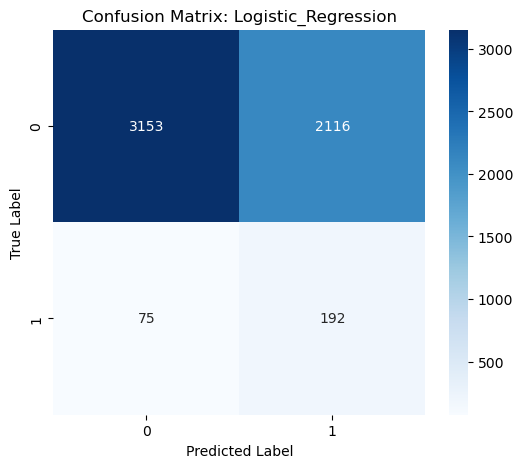

Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\Logistic_Regression_roc_curve.png


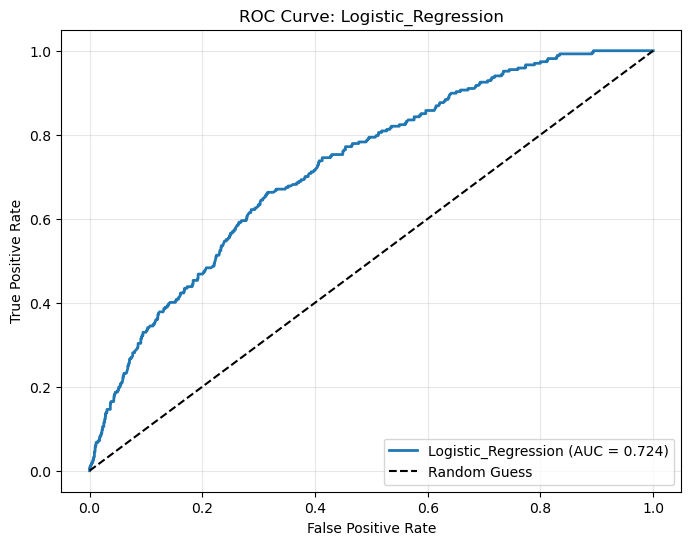

Logistic_Regression completed.

PROCESSING MODEL: Random_Forest
Model saved successfully at: E:\IIT\IRP\results\models\baseline\Random_Forest.joblib

Model Performance: Random_Forest
AUC-ROC: 0.7064
F1-Score: 0.1744

Classification Report:
              precision    recall  f1-score   support

    Survivor       0.97      0.83      0.89      5269
   Mortality       0.11      0.42      0.17       267

    accuracy                           0.81      5536
   macro avg       0.54      0.62      0.53      5536
weighted avg       0.92      0.81      0.86      5536

Report saved successfully at: E:\IIT\IRP\results\metrics\baseline\Random_Forest.txt
Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\Random_Forest_confusion_matrix.png


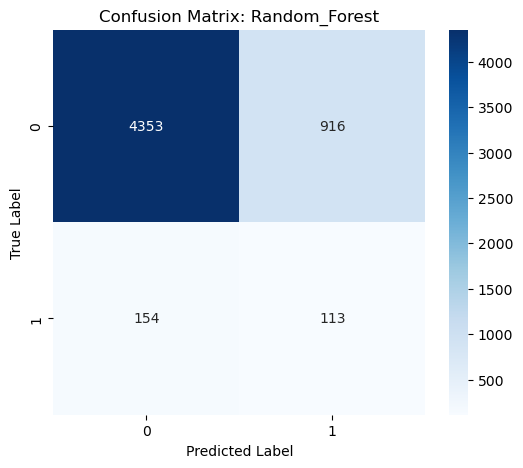

Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\Random_Forest_roc_curve.png


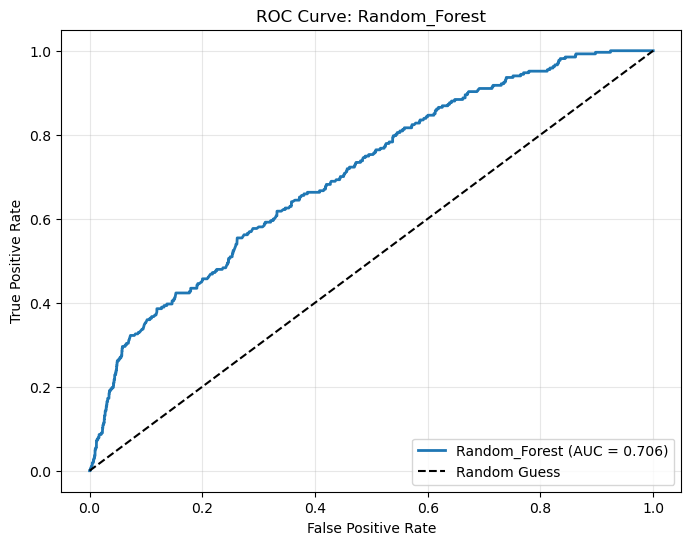

Random_Forest completed.

PROCESSING MODEL: XGBoost
Model saved successfully at: E:\IIT\IRP\results\models\baseline\XGBoost.joblib


c:\Users\damitha\.conda\envs\irp_gpu\lib\site-packages\xgboost\training.py:199: UserWarning: [10:18:18] WARNING: D:\bld\xgboost-split_1768313916136\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Performance: XGBoost
AUC-ROC: 0.6431
F1-Score: 0.1415

Classification Report:
              precision    recall  f1-score   support

    Survivor       0.96      0.94      0.95      5269
   Mortality       0.12      0.16      0.14       267

    accuracy                           0.90      5536
   macro avg       0.54      0.55      0.55      5536
weighted avg       0.92      0.90      0.91      5536

Report saved successfully at: E:\IIT\IRP\results\metrics\baseline\XGBoost.txt
Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\XGBoost_confusion_matrix.png


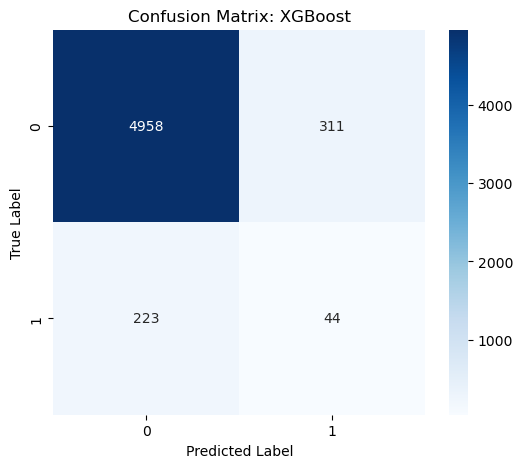

Figure saved successfully at: E:\IIT\IRP\results\figures\baseline\XGBoost_roc_curve.png


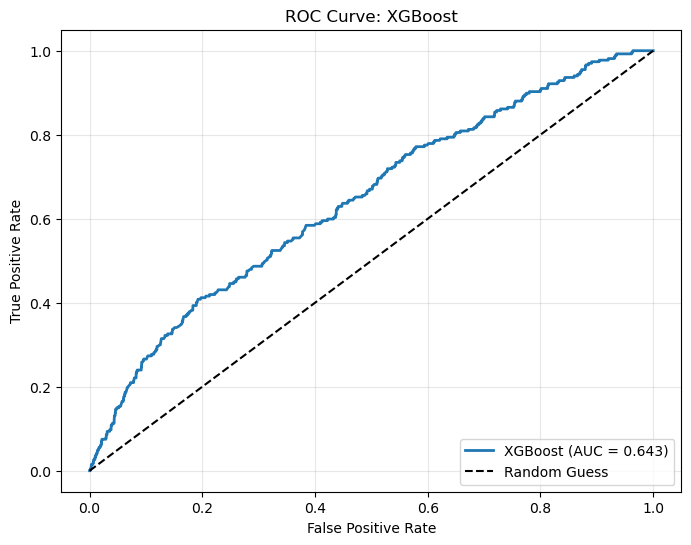

XGBoost completed.

All Baseline Models Evaluated.


In [16]:
print("\n--- Starting Training Pipeline ---")

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"PROCESSING MODEL: {name}")
    print(f"{'='*60}")
    
    # A. Train
    model.fit(X_train, y_train)
    save_model(name, model, "baseline") # Save to disk
    
    # B. Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # C. Metrics
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['Survivor', 'Mortality'])
    
    # --- DISPLAY & SAVE REPORT ---
    print(f"\nModel Performance: {name}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(report) # <--- View in Notebook
    save_report(name, report, "baseline", auc=auc, f1=f1) # Save to disk
    
    # --- DISPLAY & SAVE CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    
    save_figure(name, fig_cm, "baseline", filename_suffix="confusion_matrix") # Save
    plt.show() # <--- View in Notebook
    
    # --- DISPLAY & SAVE ROC CURVE ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fig_roc, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", lw=2)
    ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax.set_title(f'ROC Curve: {name}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    
    save_figure(name, fig_roc, "baseline", filename_suffix="roc_curve") # Save
    plt.show() # <--- View in Notebook
    
    print(f"{name} completed.")

print("\nAll Baseline Models Evaluated.")